<a href="https://colab.research.google.com/github/mservinvalencia-pixel/python/blob/main/Copia_de_Second_Checkpoint_Diplodatos_MAI_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## **Chun Rate Bancario**

---
# **Resumen Ejecutivo**
En nuestro trabajo nos centramos en predecir la probabilidad de que un cliente abandone el banco (churn). Mediante el analisis de los datos tratamos de identificar que factores clave influyen en la decisión de abandonar la entidad.
Análisis Exploratorio de datos (EDA):
Mediante el EDA encontramos un desbalance significativo en los datos, donde la mayoría de los clientes no abandonan el banco. Además con el analisis encontramos algunos patrones interesantes en cuanto al abandono:
* **Perfil del cliente**: Clientes de mayor edad y con mayor salto son más propensos al churn.
* **Geografía**: en los países analizados hay diferencias entre las tasas de churn, podría ser indicativo de algun problema o diferencia cultural entre regiones.
* **Correlaciones**: Hay ciertas correlaciones destacables como en el saldo y antiguedad del cliente que indican que hay una relación entre dichas variables y la decisión de permanecer en el banco.
Valores Atípicos: Se encontraron valores atípicos en variables como saldo y créditos, que si bien no es una cantidad considerable es importante tenerlo en cuenta al momento de seleccionar técnicas de modelado que puedan gestionarlos correctamente.

**Conclusiones del EDA:**

El EDA permitió identificar características claves que influyen en la decisión de los clientes de abandonar el banco. La edad, el saldo y país, muestran tener un impacto considerable en la tasa de churn. Esto hallazgos van a tener impacto para la selección de técnicas de preprocesamiento a aplicar las etapas siguientes como estandarización de variables numéricas y el uso de métodos como el uso de SMOTE debido al fuerte desbalance de la variable objetivo y en la selección de técnicas adecuadas de machine learning para estos casos.

**Recomendaciones**:
* Segmentación de clientes: Implementar estrategias de retención enfocadas en los segmentos de clientes y diferenciados por región geográfica
* Análisis de la experiencia del cliente: Realizar encuestas para encontrar lo que provoca insatisfacción a los clientes que los lleva a mayor churn
* Optimización de la oferta de productos y servicios: Personalizar la oferta de productos y servicios a clientes con mayor riesgo de churn



# **Introducción:**

Se realizará un análisis sobre la tasa de abandono de clientes en una entidad bancaria. El propósito principal es predecir qué clientes son más propensos a abandonar el banco (churn) encontrando patrones relevantes en el analisis exploratorio de datos y en una etapa posterior mediante la aplicación de varios modelos de Machine Learning, entre los cuales se incluyen Random Forest, XGBoost y Regresión Logística. Para abordar el desbalance en las clases, se ha aplicado la técnica de sobremuestreo SMOTE. Este análisis se basa en un dataset que contiene información demográfica e historial de clientes en el banco.

# Librerias y carga de datos

In [1]:
# Importaciones de librerías estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Estilos para los gráficos
plt.style.use('ggplot')

# Modelos y métodos de scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve

# Modelos de XGBoost
from xgboost import XGBClassifier

# Métodos de balanceo de imbalanced-learn
from imblearn.over_sampling import SMOTE

# Métodos adicionales de statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

url = 'https://raw.githubusercontent.com/pjr95/DiploDataScience/main/Churn_Modelling.csv'

churn_base = pd.read_csv(url)
#nuevo df
churn2 = pd.read_csv(url)

# Análisis Inicial de Datos

**Vista previa general de los datos:**

In [2]:
# Vista Previa de Datos
churn_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
# @title
# Forma del Data Frame
print("\nForma del DataFrame:")
churn_base.shape


Forma del DataFrame:


(10000, 14)

In [ ]:
# @title
print("\nPrimeras filas del Data frame:")
churn_base.head()


Primeras filas del Data frame:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# @title
print("\nÚltimas filas de los datos")
churn_base.tail()


Últimas filas de los datos


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [ ]:
# @title
#Variables numéricas
print("\nDescripción general de variables numéricas")
churn_base_descr = churn_base.iloc[:, 2:]
summary = churn_base_descr.describe().round(2 )
summary


Descripción general de variables numéricas


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


* Age: La edad media es de 38.92 años, con un rango desde los 18 hasta los 92 años.
* Tenure: El tiempo medio que los clientes han estado con el banco es de aproximadamente 5 años. Algunos clientes han estado hasta 10 años.
Balance: Hay una gran desviación estándar (62,397.41), indicando una dispersión significativa en los saldos de los clientes. El 25% de los clientes tiene un saldo de 0.
* HasCrCard: El 71% de los clientes tiene tarjeta de crédito.
* IsActiveMember: Solo el 52% de los clientes son miembros activos.
* Exited: El 20% de los clientes ha dejado el banco (Exited=1), lo cual es la variable objetivo de nuestro análisis de churn.

In [ ]:
# @title
#variables categóricas
print("\nDescripción de variables categóricas")
sumary_categorical = churn_base.describe(include=["object"])
sumary_categorical


Descripción de variables categóricas


,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


* Geography: Los clientes provienen principalmente de tres regiones: Francia, España y Alemania. La mayoría de los clientes son de Francia (5014).
* Gender: La proporción de género muestra una ligera mayoría de hombres (54.57%) frente a mujeres (45.43%).

In [ ]:
# @title
# Análisis de Valores Faltantes
print("\nValores nulos en cada columna:")
churn_base.isnull().sum()


Valores nulos en cada columna:


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


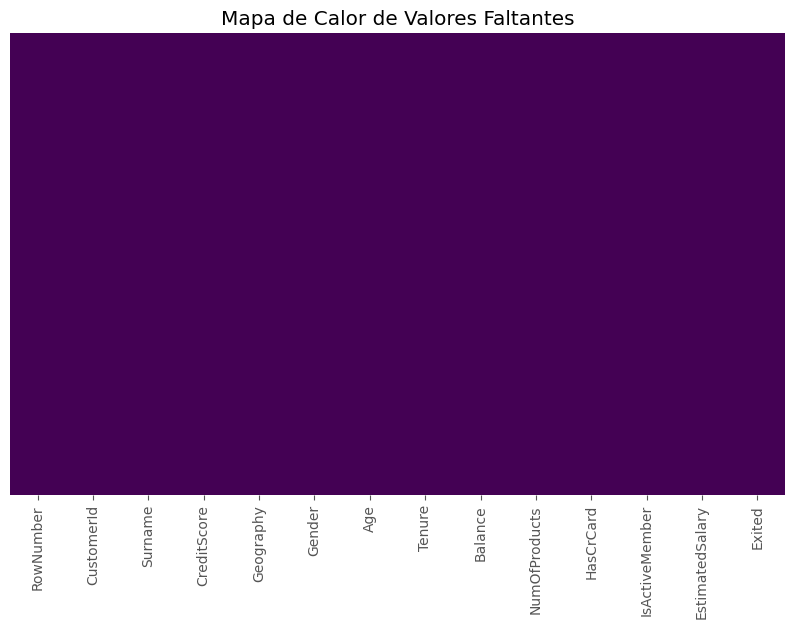

In [ ]:
# @title
# Valores faltantes
plt.figure(figsize=(10, 6))
sns.heatmap(churn_base.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Faltantes')
plt.show()

Este gráfico de calor muestra la ausencia de valores faltantes en todas las columnas del conjunto de datos, por lo que no será necesario tratamientos para que no será necesario realizar tratamientos para completar estos valores.

In [ ]:
# @title
# 4. Valores duplicados
print("\nNúmero de filas duplicadas:")
churn_base.duplicated().sum()


Número de filas duplicadas:


0

No se han encontrado filas duplicadas, por lo que no será necesario aquí hacer correcciones para tal fin.

# Análisis Univariado

Análisis de Variables Categóricas
Se eligieron gráficos de barras para representar la frecuencia de las categorías en variables como el género, país y si tiene tarjeta, etc. Los gráficos elegidos de barras permiten una rápida visualización de las proporciones de cada categoría, que es fundamental para identificar patrones en los datos.
Análisis para Variables Numéricas:
Se realiza mediante histogramas y gráficos de densidad son útiles para identificar la forma de la distribución (simetría, sesgo, kurtosis) y para detectar posibles valores atípicos o outliers. Esto es esencial para entender la dispersión y centralización de las variables numéricas clave.

* No se observan valores nulos ni duplicados.



4. Análisis de la Variable Objetivo (Churn)


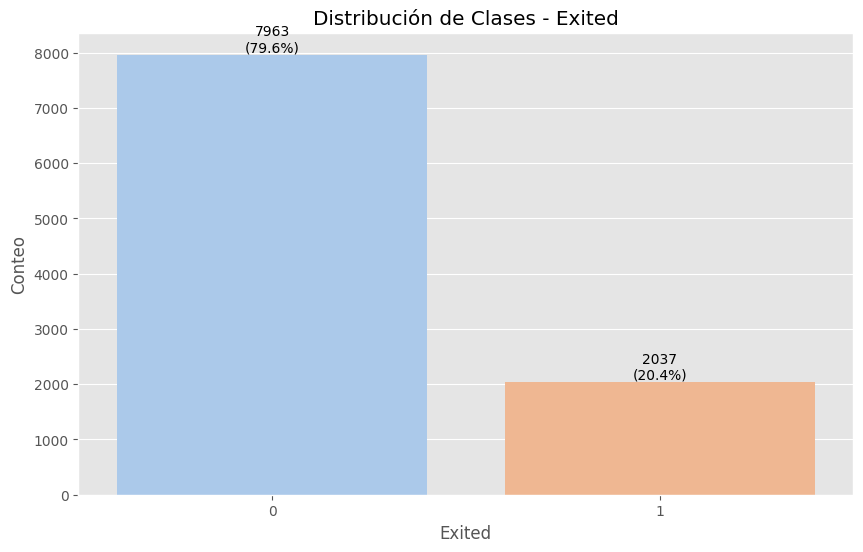

In [ ]:
# @title
# Análisis de la Variable Objetivo (Churn)
print("\n4. Análisis de la Variable Objetivo (Churn)")
# Conteo de valores
value_counts = churn_base['Exited'].value_counts().reset_index()
value_counts.columns = ['Exited', 'Count']

# Cálculo de porcentajes
value_percentages = churn_base['Exited'].value_counts(normalize=True) * 100

#  Visualización con gráfico de barras de diferentes colores
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Exited', y='Count', data=value_counts, hue='Exited', palette='pastel', legend=False)
plt.title('Distribución de Clases - Exited')
plt.xlabel('Exited')
plt.ylabel('Conteo')

# Añadir etiquetas de texto a las barras
for i, v in enumerate(value_counts['Count']):
    ax.text(i, v, f'{v}\n({value_percentages[i]:.1f}%)', ha='center', va='bottom')

plt.show()

* Existe un desbalance significativo en la variable objetivo: 80% de los clientes no abandonaron (0) vs 20% que sí lo hicieron (1)

# Prueba de hipótesis para la Diferencia de Proporciones entre Exited y No Exited

In [ ]:
import statsmodels.api as sm

# Datos
proporcion_exited = 0.796
proporcion_no_exited = 0.204
n_exited = 7963
n_no_exited = 2037

# Proporciones observadas
p1 = proporcion_exited
p2 = proporcion_no_exited

# Tamaños de muestra
n1 = n_exited
n2 = n_no_exited

# Diferencia observada de proporciones
diferencia_observada = p1 - p2

# Crear un array con los conteos de éxitos y fracasos
count = np.array([p1 * n1, p2 * n2])
nobs = np.array([n1, n2])

# Prueba de hipótesis para la diferencia de dos proporciones
zscore, pvalue = sm.stats.proportions_ztest(count, nobs)

# Resultados
print(f"Z-score: {zscore}")
print(f"P-value: {pvalue}")

if pvalue < 0.05:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa entre las dos proporciones.")
else:
    print("No podemos rechazar la hipótesis nula: No hay una diferencia significativa entre las dos proporciones.")

Z-score: 50.92184480050684
P-value: 0.0
Rechazamos la hipótesis nula: Hay una diferencia significativa entre las dos proporciones.


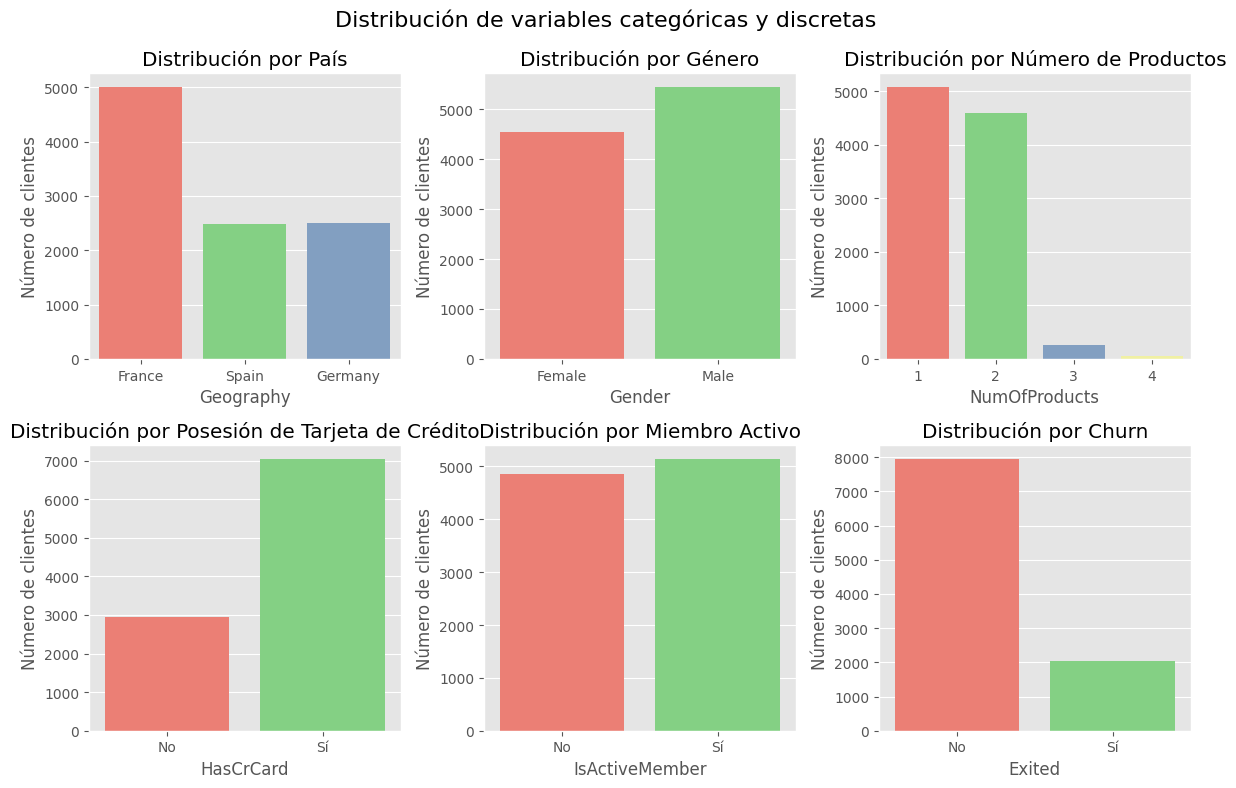

In [ ]:
# @title
pastel_colors = ['#FF6F61', '#77DD77', '#779ECB', '#FDFD96', '#FFB347', '#C39BD3']

fig, axs = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Distribución de variables categóricas y discretas', fontsize=16)

# Geography
sns.countplot(x='Geography', data=churn_base, ax=axs[0, 0], hue='Geography', palette=pastel_colors[:3], legend=False)
axs[0, 0].set_title('Distribución por País')
axs[0, 0].set_ylabel('Número de clientes')

# Gender
sns.countplot(x='Gender', data=churn_base, ax=axs[0, 1], hue='Gender', palette=pastel_colors[:2], legend=False)
axs[0, 1].set_title('Distribución por Género')
axs[0, 1].set_ylabel('Número de clientes')

# NumOfProducts
sns.countplot(x='NumOfProducts', data=churn_base, ax=axs[0, 2], hue='NumOfProducts', palette=pastel_colors[:4], legend=False)
axs[0, 2].set_title('Distribución por Número de Productos')
axs[0, 2].set_ylabel('Número de clientes')

# HasCrCard
sns.countplot(x='HasCrCard', data=churn_base, ax=axs[1, 0], hue='HasCrCard', palette=pastel_colors[:2], legend=False)
axs[1, 0].set_title('Distribución por Posesión de Tarjeta de Crédito')
axs[1, 0].set_ylabel('Número de clientes')
axs[1, 0].set_xticks([0, 1])
axs[1, 0].set_xticklabels(['No', 'Sí'])

# IsActiveMember
sns.countplot(x='IsActiveMember', data=churn_base, ax=axs[1, 1], hue='IsActiveMember', palette=pastel_colors[:2], legend=False)
axs[1, 1].set_title('Distribución por Miembro Activo')
axs[1, 1].set_ylabel('Número de clientes')
axs[1, 1].set_xticks([0, 1])
axs[1, 1].set_xticklabels(['No', 'Sí'])

# Exited
sns.countplot(x='Exited', data=churn_base, ax=axs[1, 2], hue='Exited', palette=pastel_colors[:2], legend=False)
axs[1, 2].set_title('Distribución por Churn')
axs[1, 2].set_ylabel('Número de clientes')
axs[1, 2].set_xticks([0, 1])
axs[1, 2].set_xticklabels(['No', 'Sí'])

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

* Geography: La mayoría de los clientes provienen de Francia, representando más del 50% de la muestra total. Mientras que España y Alemania tienen una cantidad similar de clientes.
* Gender: Hay más hombres que mujeres en la base de clientes, con una proporción aproximada de 55% hombres y 45% mujeres.
* NumOfProducts: La mayoría de los clientes tienen uno o dos productos, siendo estos el 50% y 40% respectivamente. Muy pocos clientes tienen más de dos producto.
* HasCrCard: Aproximadamente el 70% de los clientes poseen una tarjeta de crédito, mientras que el 30% no la tiene.
* IsActiveMember: La cantidad de miembros activos y no activos está casi equilibrada, con una ligera mayoría de miembros activos (52%).

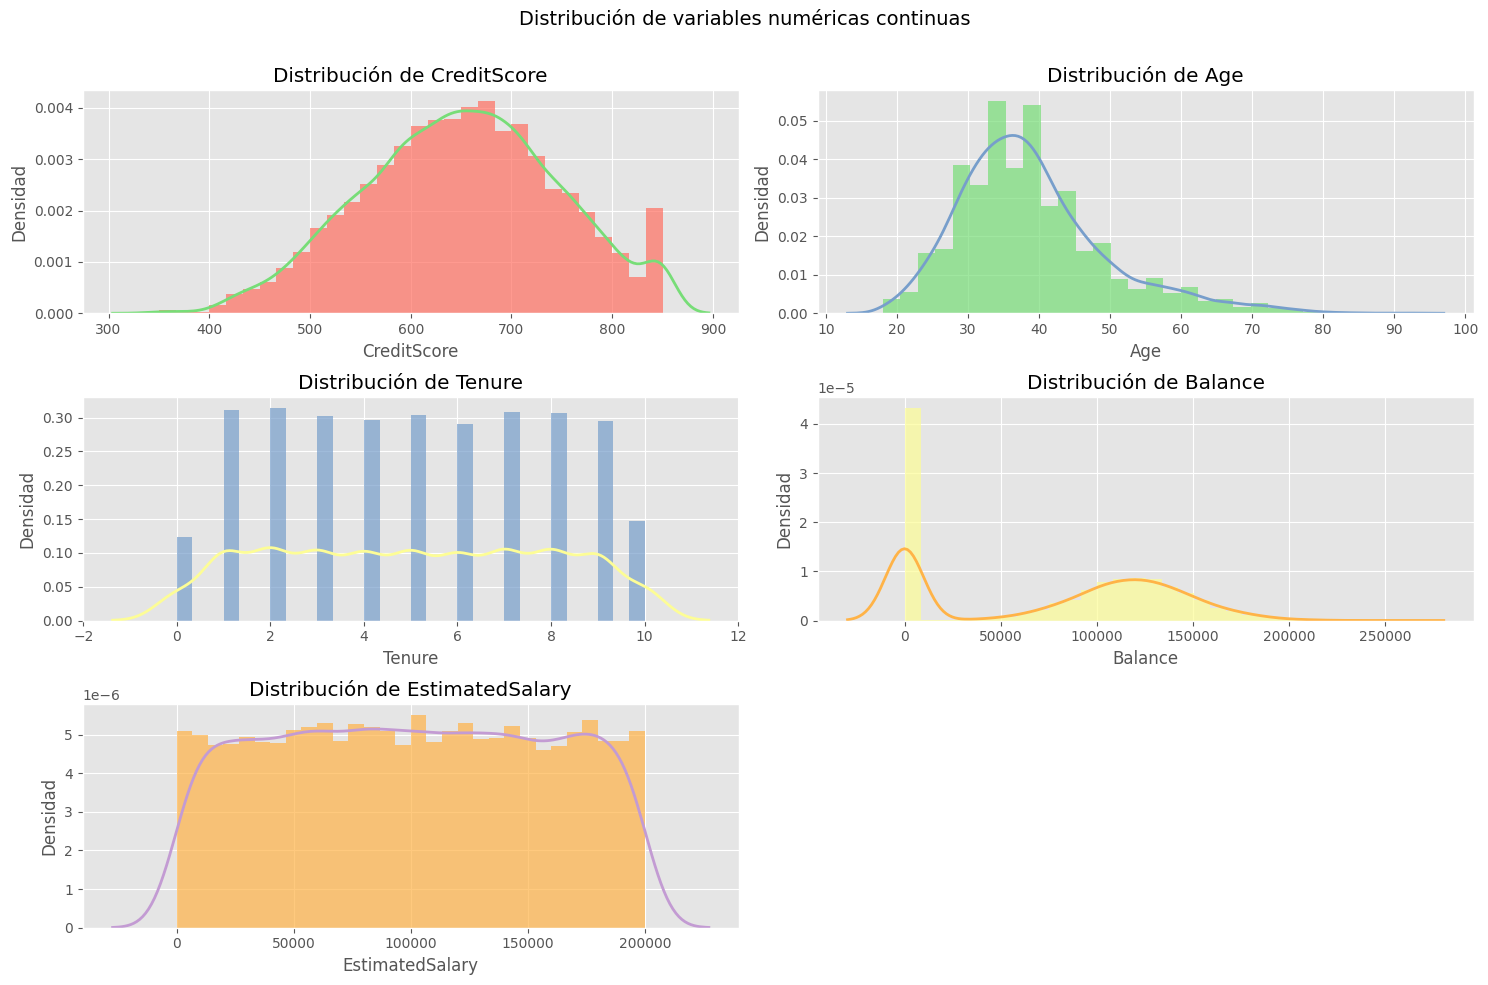

In [ ]:
# @title
pastel_colors = ['#FF6F61', '#77DD77', '#779ECB', '#FDFD96', '#FFB347', '#C39BD3']

fig, axs = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Distribución de variables numéricas continuas', fontsize=14)

# Lista de variables para los histogramas
variables = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Crear histogramas
for i, var in enumerate(variables):
    row = i // 2
    col = i % 2

    # Histograma
    axs[row, col].hist(churn_base[var], bins=30, color=pastel_colors[i], alpha=0.7, density=True)

    # Línea KDE
    sns.kdeplot(data=churn_base, x=var, ax=axs[row, col],
                color=pastel_colors[(i+1) % len(pastel_colors)], linewidth=2)

    axs[row, col].set_title(f'Distribución de {var}')
    axs[row, col].set_xlabel(var)
    axs[row, col].set_ylabel('Densidad')
    axs[row, col].locator_params(axis='x', nbins=10)

# Eliminar el subplot extra
axs[2, 1].remove()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

* CreditScore: La distribución del puntaje de crédito tiene forma aproximadamente normal, con una ligera asimetría negativa.La mayoría de los clientes tienen un puntaje de crédito entre 600 y 700.
*  Age: La edad tiene una distribución con asimetría positiva, con un pico alrededor de los 35-40 años. La mayoría de los clientes tienen entre 30 y 50 años.
* Tenure: El tiempo de permanencia de los clientes está bastante distribuido uniformemente entre 1 y 9 años.
* Balance:Hay una  gran cantidad de clientes con saldo cero.Hay un segundo pico de clientes con saldos alrededor de 100,000 a 150,000.
* EstimatedSalary:Tiene una distribución casi uniforme en su rango.

# Análisis Bivariado

Análisis de la Distribución de Variables Numéricas por Estado de Churn
Aqui se identifican patrones en las variables numéricas (puntaje de crédito, edad, antigüedad, saldo, salario) que diferencien a los clientes que se fueron (churn) de los que se quedaron.
Se utilizaron histogramas y curvas de densidad (KDE) para visualizar la distribución de cada variable en ambos grupos de clientes.
Esto ayuda a comparar fácilmente las distribuciones y detectar diferencias significativas.

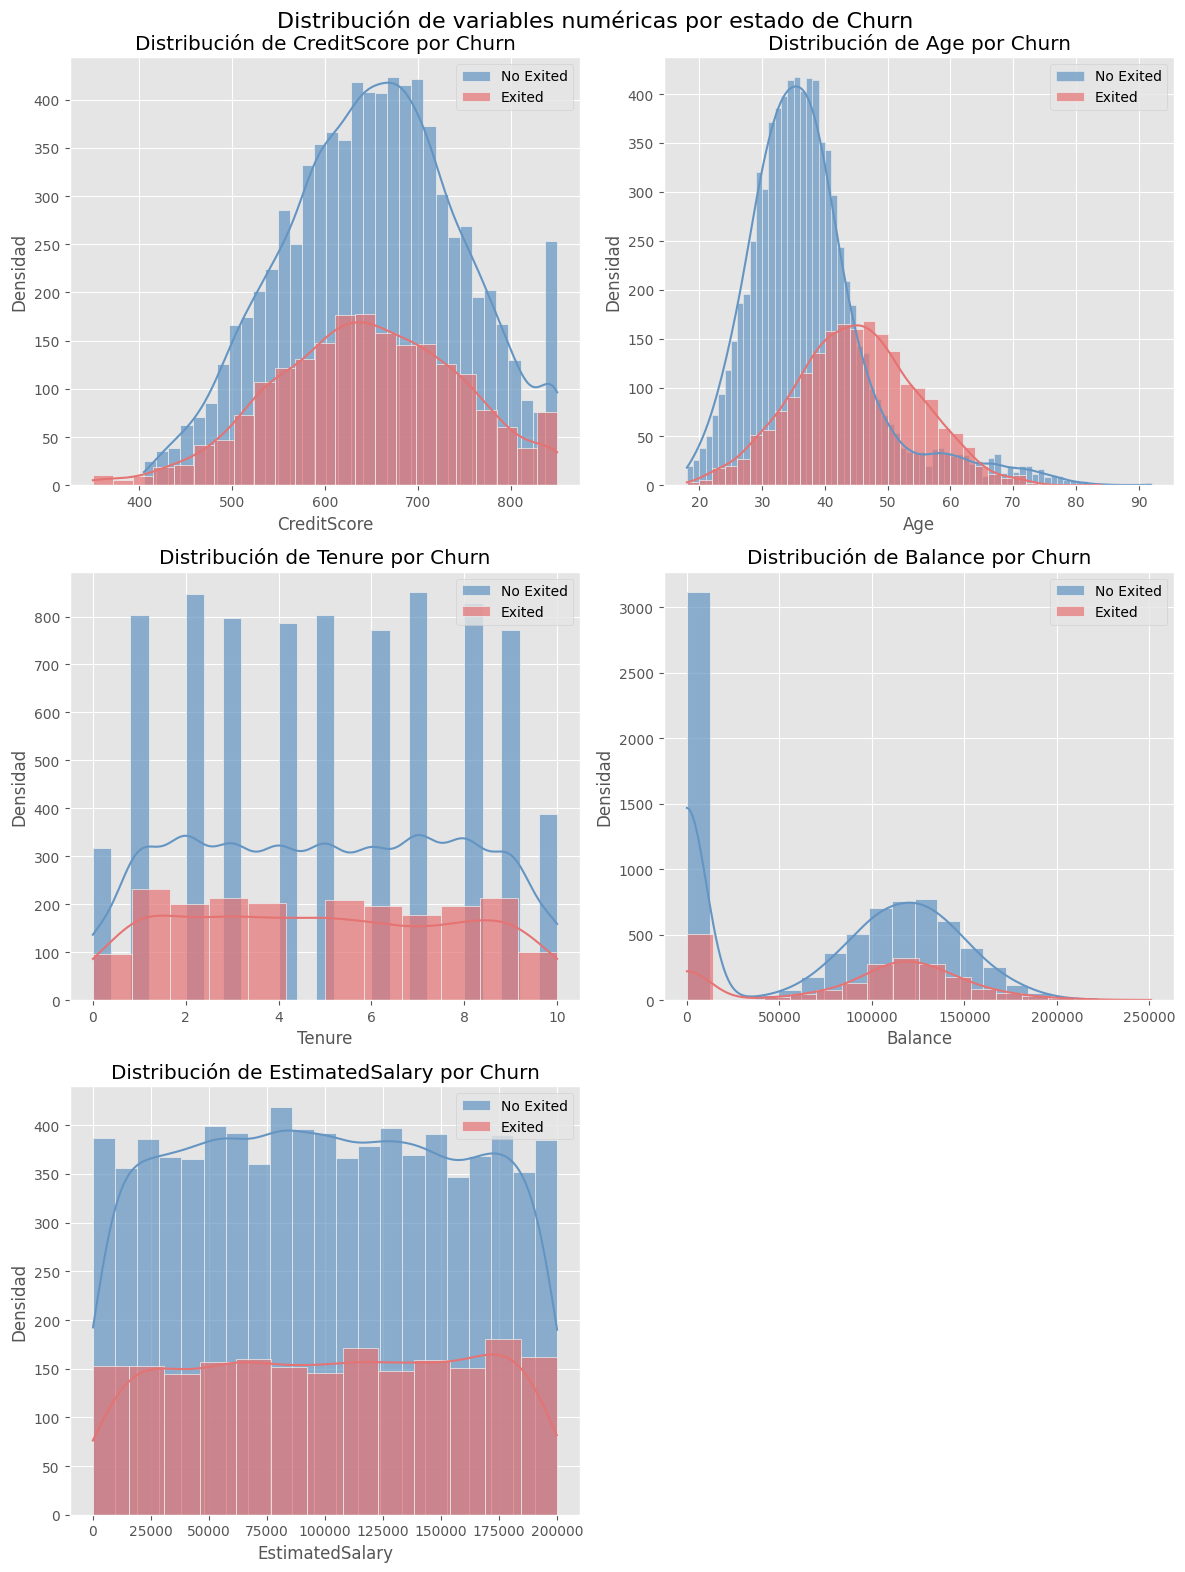

In [ ]:
# @title
# Definir colores pastel
pastel_blue = '#6495C2'
pastel_red = '#E57373'


# Lista de variables numéricas continuas
numeric_vars = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Crear subplot para cada variable
fig, axs = plt.subplots(3, 2, figsize=(12, 16))
fig.suptitle('Distribución de variables numéricas por estado de Churn', fontsize=16)

# Aplanar la matriz de ejes para facilitar la iteración
axs = axs.flatten()

# Crear gráficos de densidad
for i, var in enumerate(numeric_vars):
    # Gráfico de densidad para Exited = 0
    sns.histplot(data=churn_base[churn_base['Exited'] == 0], x=var, kde=True,
                 color=pastel_blue, alpha=0.7, label='No Exited', ax=axs[i])

    # Gráfico de densidad para Exited = 1
    sns.histplot(data=churn_base[churn_base['Exited'] == 1], x=var, kde=True,
                 color=pastel_red, alpha=0.7, label='Exited', ax=axs[i])

    axs[i].set_title(f'Distribución de {var} por Churn')
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Densidad')
    axs[i].legend()

# Eliminar el subplot extra
axs[5].remove()

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

Variables numéricas en el contexto del Churn:
* CreditScore:si bien hay una relación entre un CreditScore bajo y una mayor probabilidad de churn, pero no se aprecia lo suficiente para predecir el churn, pero es un factor relevante. Un puntaje de crédito bajo puede indicar un mayor riesgo de incumplimiento, lo que podría llevar a un mayor churn.
* Age: La edad parece ser un factor significativo, ya que los clientes que han hecho churn tienden a ser más viejos. La densidad para "Exited" es mayor en las edades entre 40 y 60 años.
* Tenure: La antigüedad del cliente no parece ser determinante en el churn, la decisión de abandonar el servicio podría depender de otros factores más allá del tiempo que han sido clientes.
* Balance: El balance parece ser un factor importante en la decisión de churn, con una tendencia a que los clientes con balances intermedios sean más propensos a abandonar.
* EstimatedSalary: El salario estimado no parece ser un predictor significativo del churn.


# Prueba de Hipótesis para la diferencia de medias de Credit Score, Age, Tenure, Balance y Estimated Salary; para Exited y No Exited.

Se realiza para comparar las medias de las variables entre los clientes que han abandonado y los que no permite identificar diferencias en las características clave. Y Pruebas de Hipótesis (T-Tests) para determinar si las diferencias observadas en las medias de las variables entre los dos grupos son estadísticamente significativas.

In [ ]:
from scipy.stats import ttest_ind

# Calcular la media para cada variable numérica, agrupada por Exited
mean_values = churn_base.groupby('Exited')[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']].mean()

# Mostrar las medias
print("Medias para clientes que se han dado de baja (Exited = 1):")
print(mean_values.loc[1])
print("\nMedias para clientes que no se han dado de baja (Exited = 0):")
print(mean_values.loc[0])

# Separar los datos en dos grupos: Exited y No Exited
exited = churn_base[churn_base['Exited'] == 1]
not_exited = churn_base[churn_base['Exited'] == 0]

# Listas para almacenar los resultados de las pruebas de hipótesis
variables = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
t_statistics = []
p_values = []

# Realizar la prueba de hipótesis para cada variable
for variable in variables:
    t_stat, p_value = ttest_ind(exited[variable], not_exited[variable], equal_var=False)
    t_statistics.append(t_stat)
    p_values.append(p_value)

# Mostrar los resultados
for variable, t_stat, p_value in zip(variables, t_statistics, p_values):
    print(f"\nPrueba de hipótesis para la variable {variable}:")
    print(f"T-statistic: {t_stat}")
    print(f"P-value: {p_value}")
    if p_value < 0.05:
        print("Rechazamos la hipótesis nula: Hay una diferencia significativa entre las medias.")
    else:
        print("No podemos rechazar la hipótesis nula: No hay una diferencia significativa entre las medias.")

Medias para clientes que se han dado de baja (Exited = 1):
CreditScore           645.351497
Age                    44.837997
Tenure                  4.932744
Balance             91108.539337
EstimatedSalary    101465.677531
Name: 1, dtype: float64

Medias para clientes que no se han dado de baja (Exited = 0):
CreditScore          651.853196
Age                   37.408389
Tenure                 5.033279
Balance            72745.296779
EstimatedSalary    99738.391772
Name: 0, dtype: float64

Prueba de hipótesis para la variable CreditScore:
T-statistic: -2.6346605436575796
P-value: 0.008464728991832862
Rechazamos la hipótesis nula: Hay una diferencia significativa entre las medias.

Prueba de hipótesis para la variable Age:
T-statistic: 30.419197204406792
P-value: 4.7127272656641046e-179
Rechazamos la hipótesis nula: Hay una diferencia significativa entre las medias.

Prueba de hipótesis para la variable Tenure:
T-statistic: -1.384328819131246
P-value: 0.16635698992884443
No podemos rec

 En CreditScore, Age, y Balance hay diferencias significativas entre los grupos, que sugiere que estas características podrían ser relevantes para predecir el churn. En cambio, variables como Tenure y EstimatedSalary no muestran diferencias significativas, indicando que no tienen un impacto relevante en el abandono.

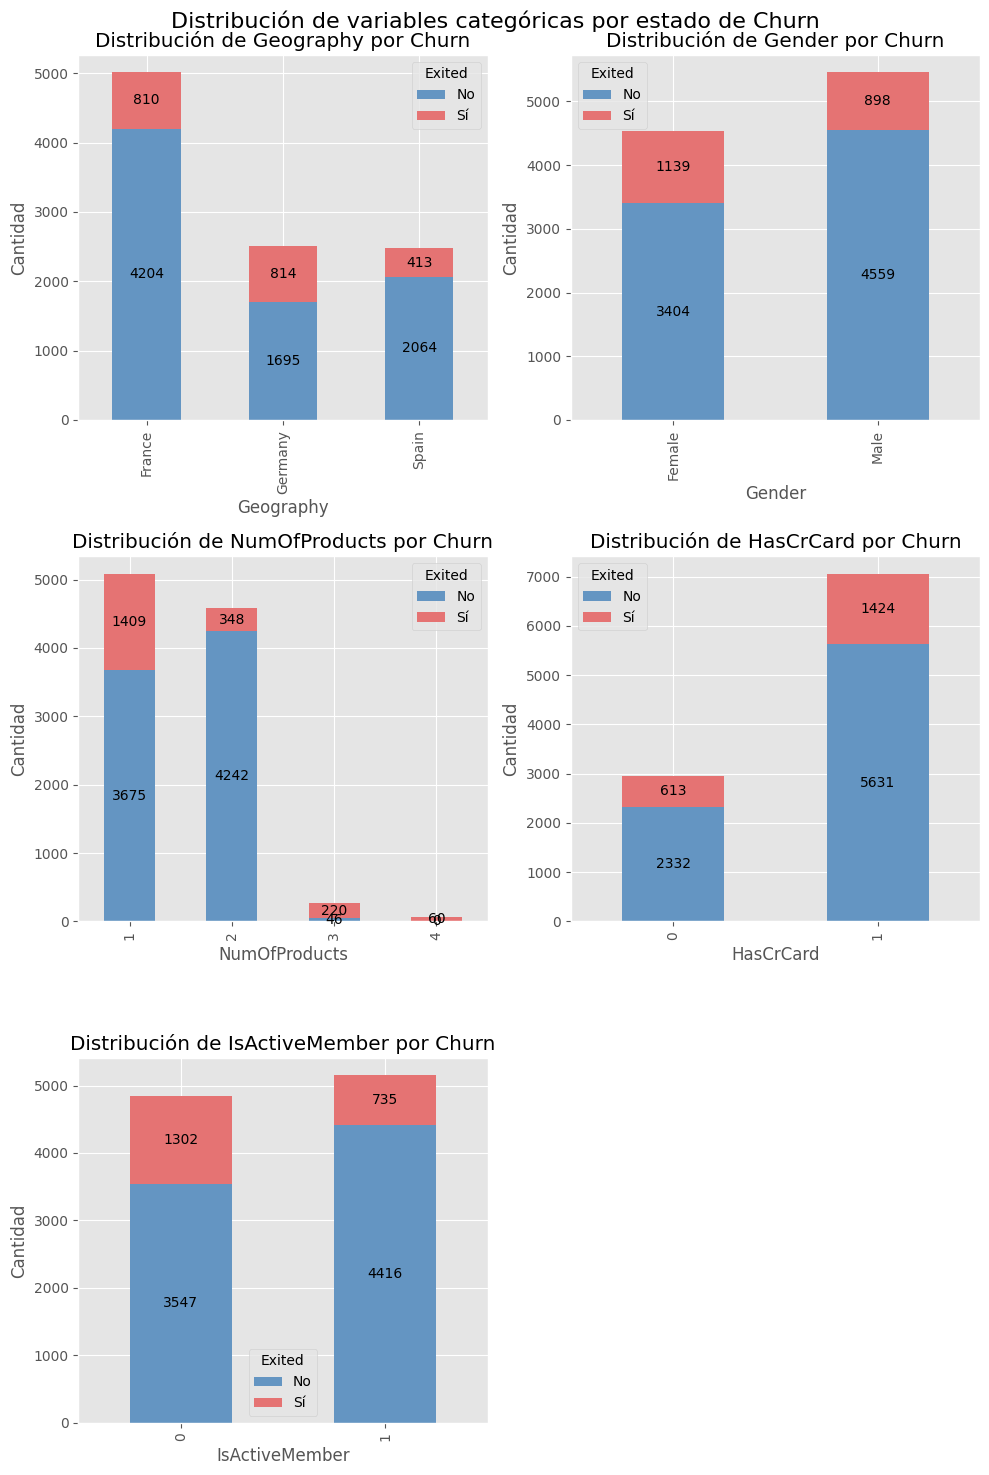

In [ ]:
# @title
# Definir colores
pastel_colors = ['#6495C2', '#E57373']

# Lista de variables categóricas
cat_vars = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

# Crear subplot para cada variable
fig, axs = plt.subplots(3, 2, figsize=(10, 15))
fig.suptitle('Distribución de variables categóricas por estado de Churn', fontsize=16)

# Aplanar la matriz de ejes para facilitar la iteración
axs = axs.flatten()

# Crear gráficos de barras apiladas
for i, var in enumerate(cat_vars):
    # Usar crosstab sin normalizar para obtener cantidades
    crosstab = pd.crosstab(churn_base[var], churn_base['Exited'])
    crosstab.plot(kind='bar', stacked=True, ax=axs[i], color=pastel_colors)
    axs[i].set_title(f'Distribución de {var} por Churn')
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Cantidad')
    axs[i].legend(title='Exited', labels=['No', 'Sí'])

    # Añadir etiquetas de cantidad en las barras
    for c in axs[i].containers:
        axs[i].bar_label(c, label_type='center')

# Eliminar el subplot extra
axs[5].remove()

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

 **Variables categóricas en el contexto del Churn:**
* Geography: La geografía parece ser relevante en el churn, con una mayor propensión a abandonar en Alemania, podrían existir factores regionales específicos que influyen en el churn.
* Gender: El género es un factor relevante en el churn, con una mayor propensión entre las mujeres.
* NumOfProducts: Los clientes con un solo producto tienen una mayor tasa de churn en comparación con aquellos que tienen dos o más productos. Los clientes con tres o más productos representan una pequeña parte del total.
* HasCrCard: Poseer tarjeta de crédito no parece estar fuertemente relacionada con el churn, aunque los que no tienen tarjeta de crédito tienen una tasa de churn un poco menor.
* IsActiveMember:  Los clientes que son miembros activos tienen menor tasa de churn en comparación con los que no lo son.


# **Pairplot de variables Numéricas:**
Esto permite visualizar las relaciones entre variables numéricas (CreditScore, Age, Tenure, Balance, NumOfProducts, EstimatedSalary) en función del estado de churn. Facilita la identificación de patrones entre las variables y cómo estos varían entre los clientes que han abandonado y los que no.
Se usa pairplot es ideal para examinar tanto las distribuciones individuales de las variables como las relaciones bivariadas entre pares de variables, lo cual ayuda a detectar correlaciones, outliers, o posibles patrones que expliquen el churn y también como estas interacciones varían según el churn o no.

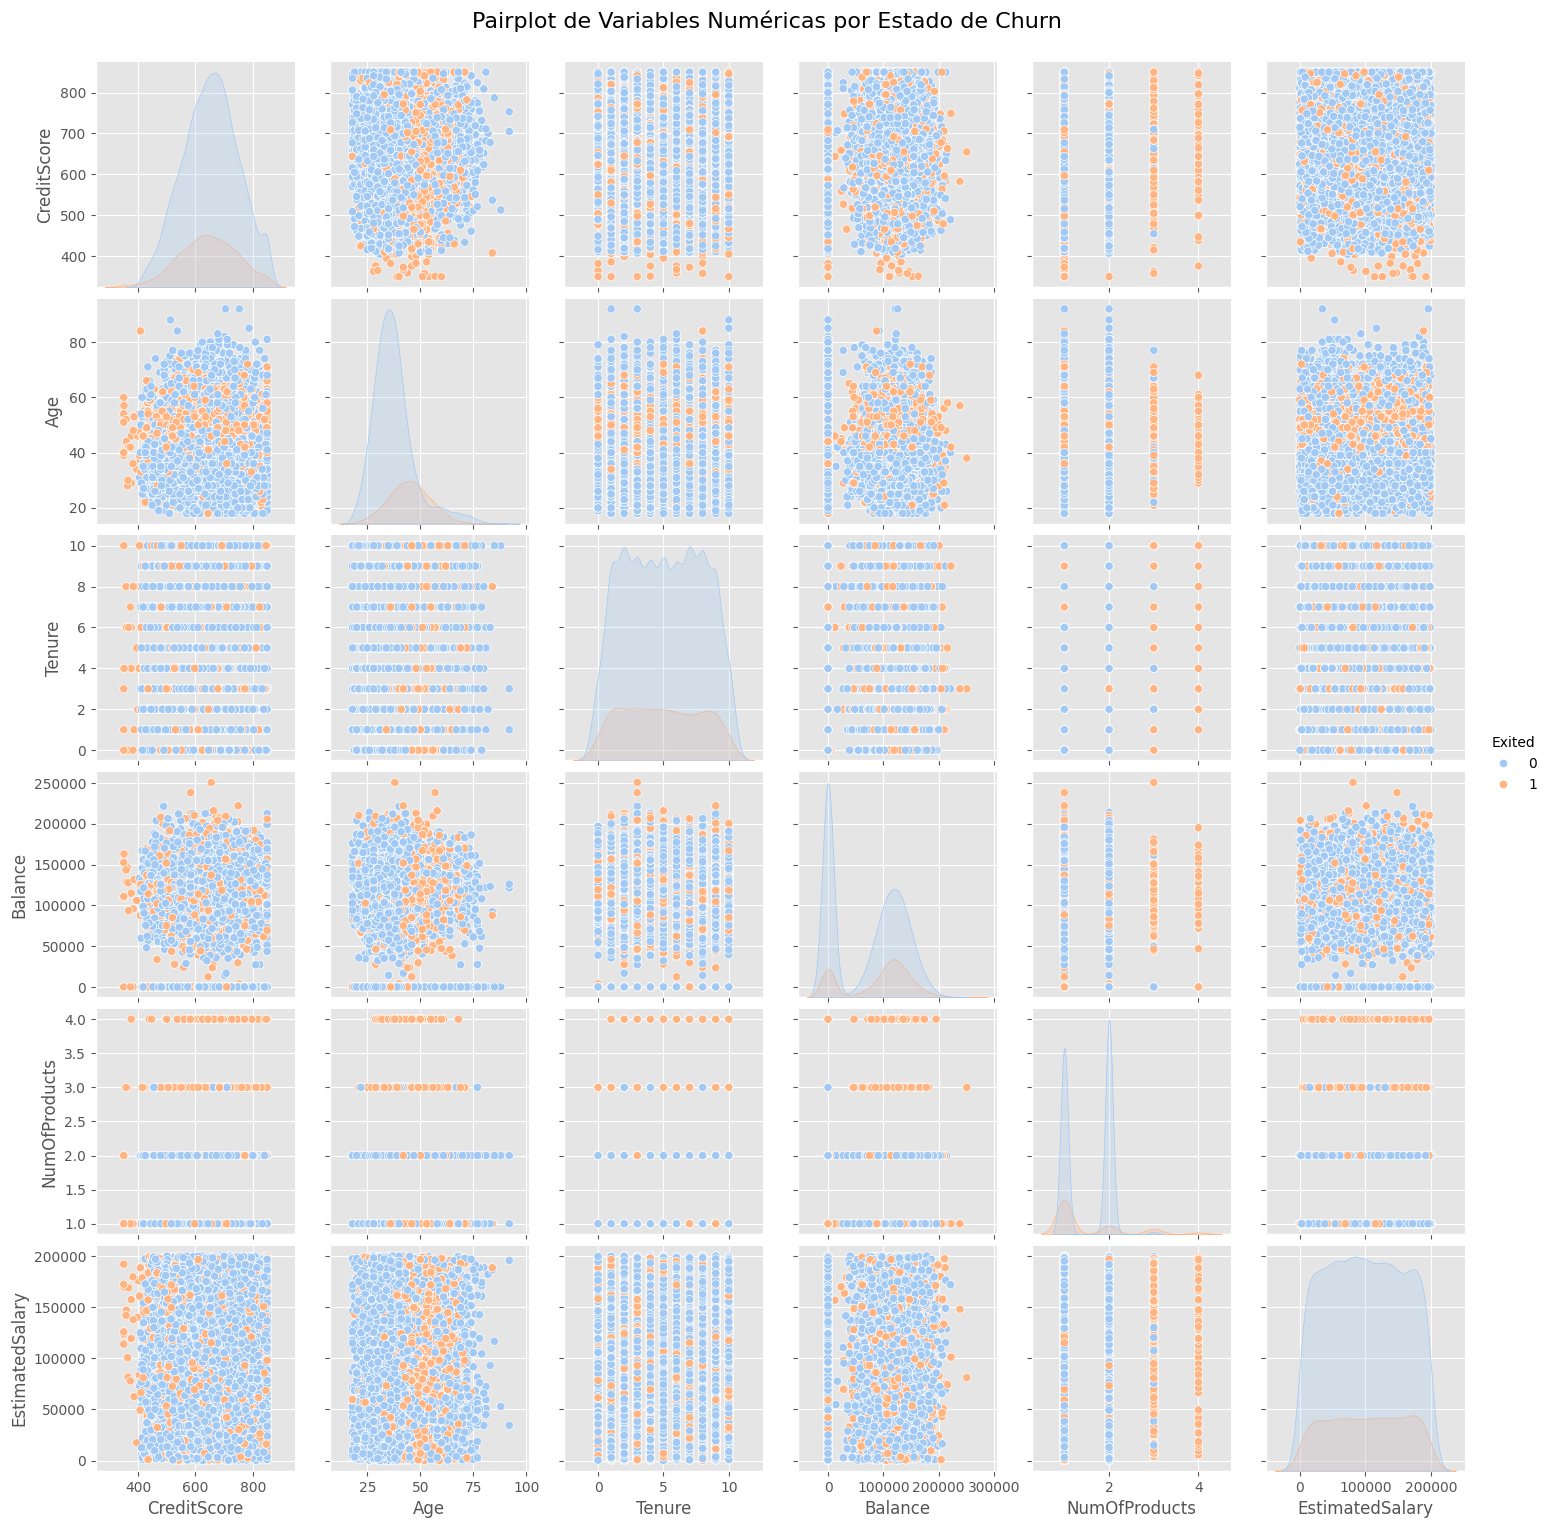

In [ ]:
# @title
# Selección las variables para el pairplot
variables = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']

# Crear el pairplot
sns.pairplot(churn_base[variables], hue='Exited', palette='pastel')
plt.suptitle('Pairplot de Variables Numéricas por Estado de Churn', y=1.02, fontsize=16)
plt.show()

* CreditScore no parece tener relaciones lineales fuertes con las demás variables.
* Age y Balance: La edad parece tener una relación notable con el balance, lo que indica que los clientes de mayor edad con balances altos son más propensos a churn.
* Tenure: La antigüedad no muestra una relación clara con otras variables.
* NumOfProducts: La cantidad de productos muestra una clara distinción en las tasas de churn, especialmente para aquellos con un solo producto, quienes tienen una mayor tasa de churn.
* EstimatedSalary: El salario estimado no muestra correlaciones evidentes con otras variables ni con el churn.


# **Analisis mediante Boxplot:**
Se usaron aquí para comparar numéricas clave (CreditScore, Age, Tenure, Balance, EstimatedSalary) entre los clientes que abandonaron y los que no para ver diferencias en las medianas y la dispersión de los datos, así como la presencia de posibles outliers.
Se usaron boxplots ya que proporcionan una representación visual concisa de la distribución de cada variable y permiten una comparación efectiva entre los grupos de churn.

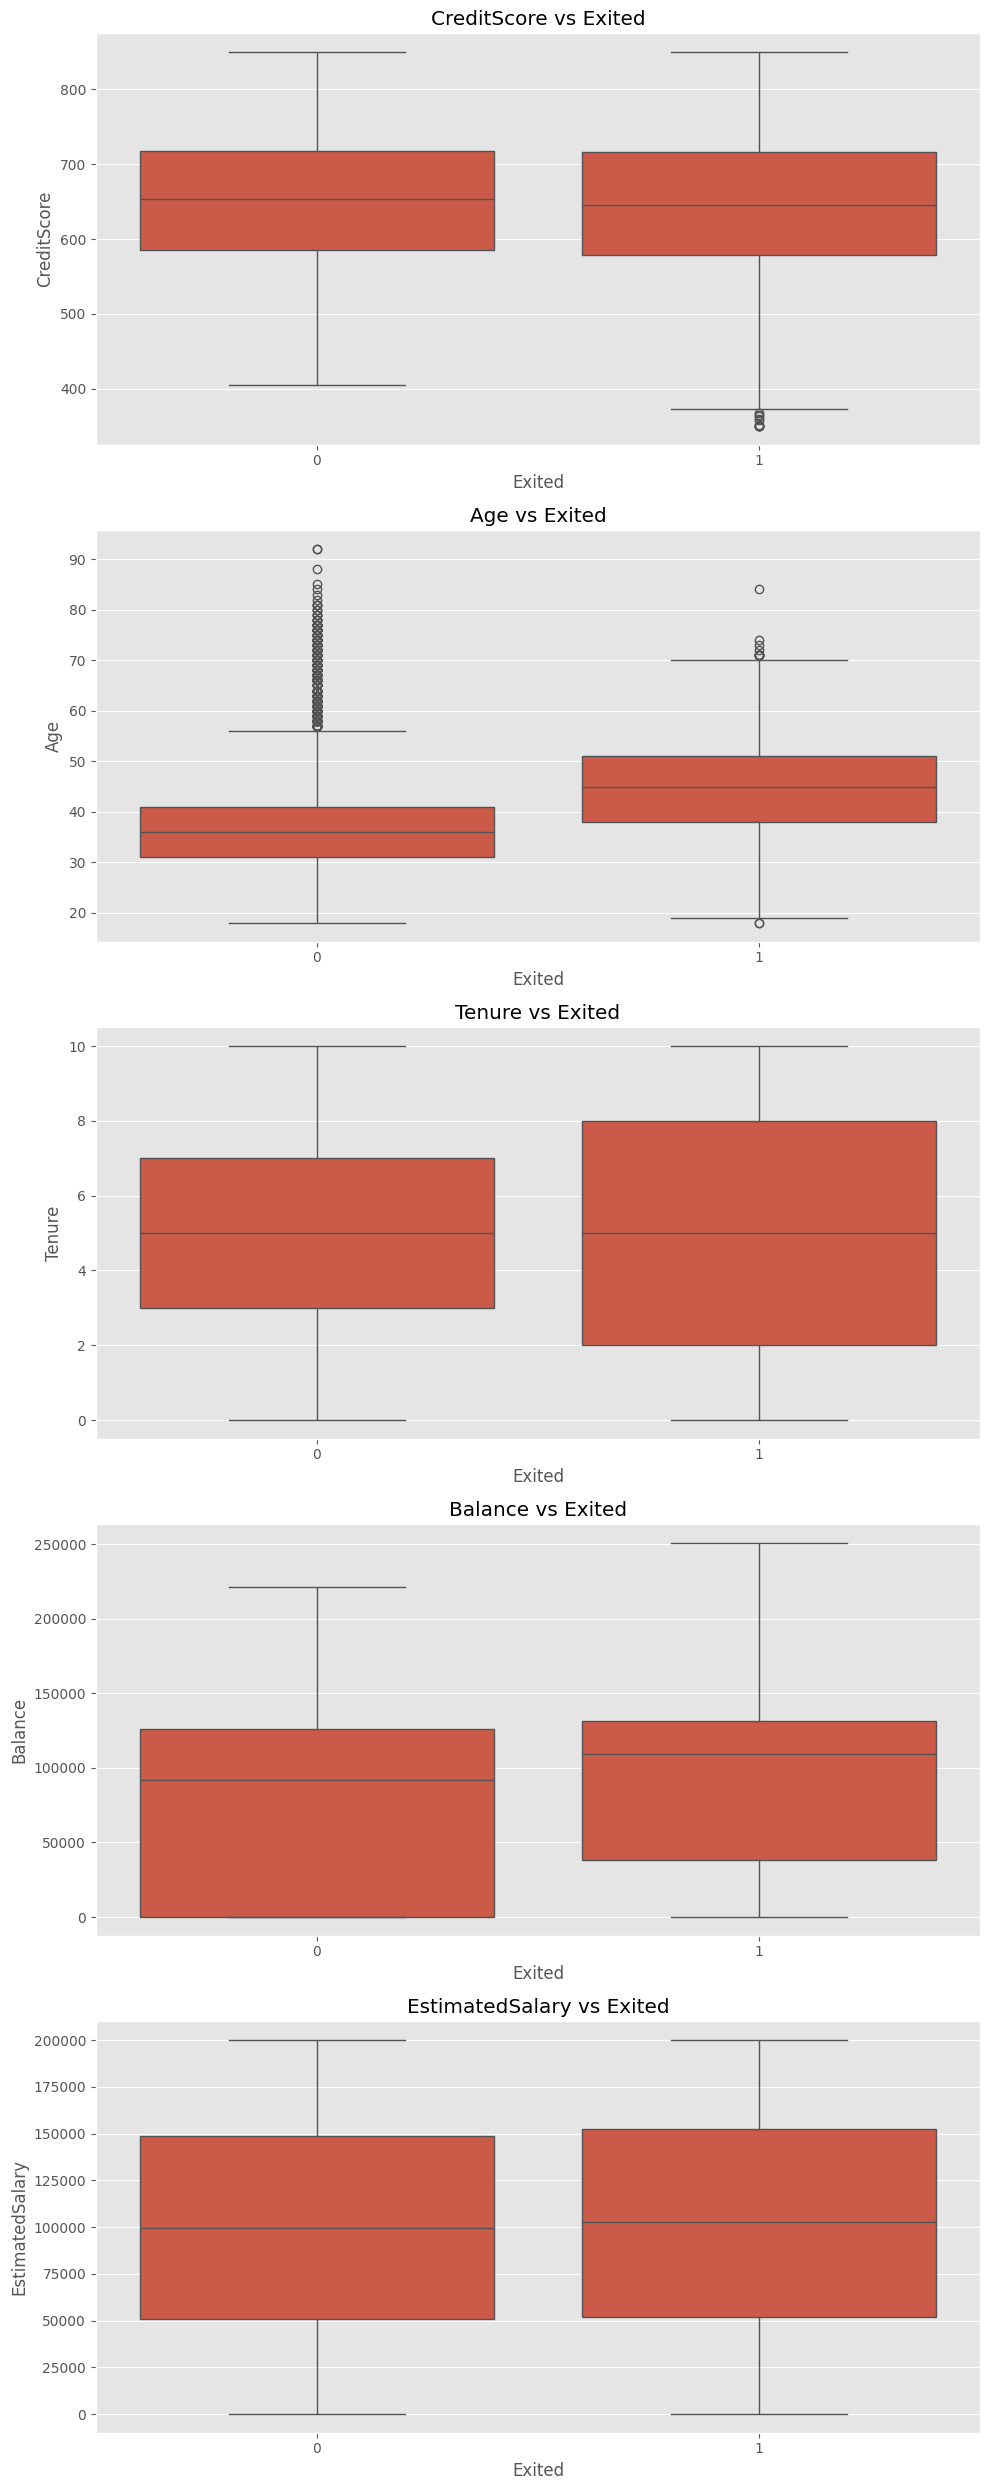

In [ ]:
# @title
# Boxplot Para variables numéricas
numeric_vars = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axs = plt.subplots(len(numeric_vars), 1, figsize=(10, 5*len(numeric_vars)))
for i, var in enumerate(numeric_vars):
    sns.boxplot(x='Exited', y=var, data=churn_base, ax=axs[i])
    axs[i].set_title(f'{var} vs Exited')
plt.tight_layout()
plt.show()

# Análisis Multivariado


7. Análisis de Correlación


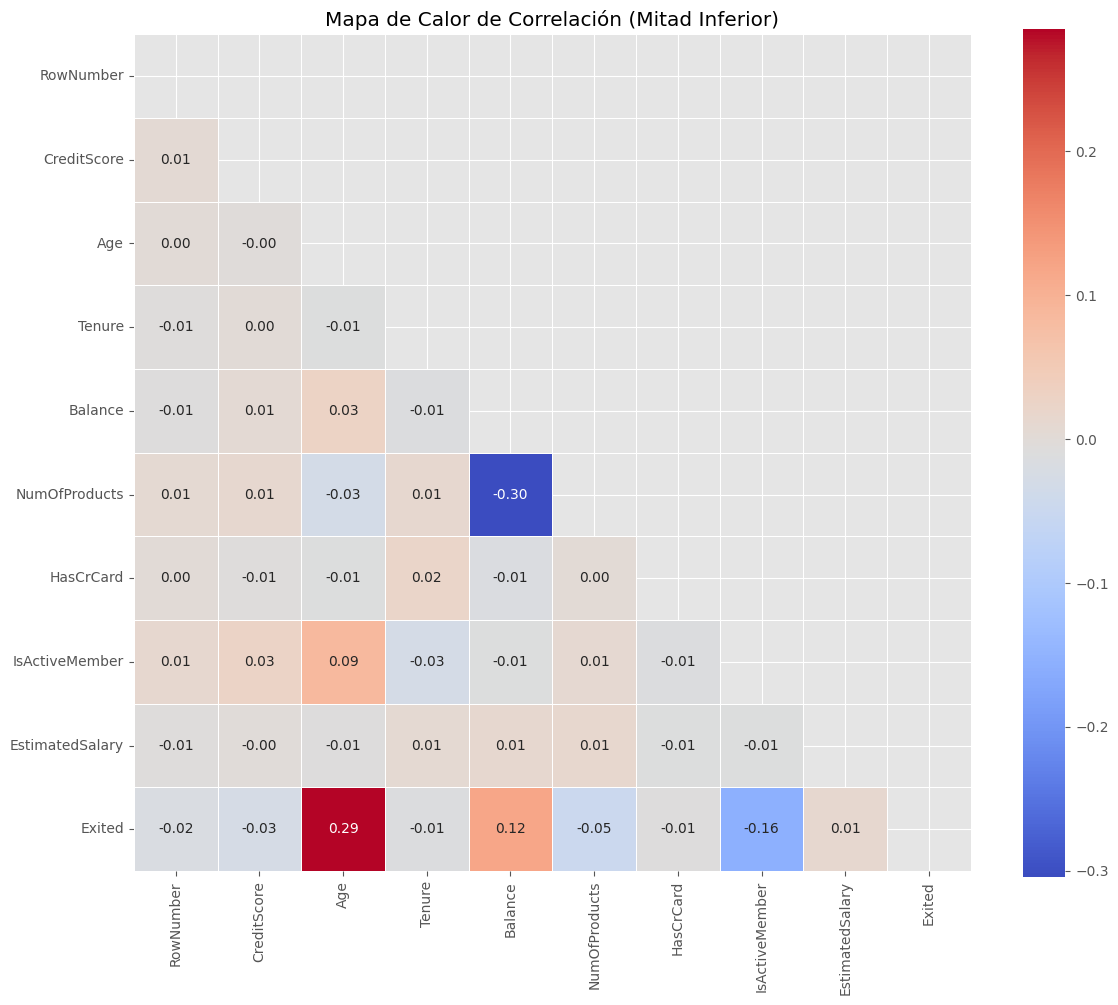

In [ ]:
# @title
# Análisis de Correlación
print("\n7. Análisis de Correlación")

# Seleccionar columnas numéricas, excluyendo 'Rownumber' y 'CustomerId'
numeric_cols = churn_base.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['Rownumber', 'CustomerId']]

# Calcular la matriz de correlación
corr_matrix = churn_base[numeric_cols].corr()

# Crear una máscara para la mitad superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Crear un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            fmt='.2f',
            square=True)
plt.title('Mapa de Calor de Correlación (Mitad Inferior)')
plt.tight_layout()
plt.show()

NameError: name 'X' is not defined

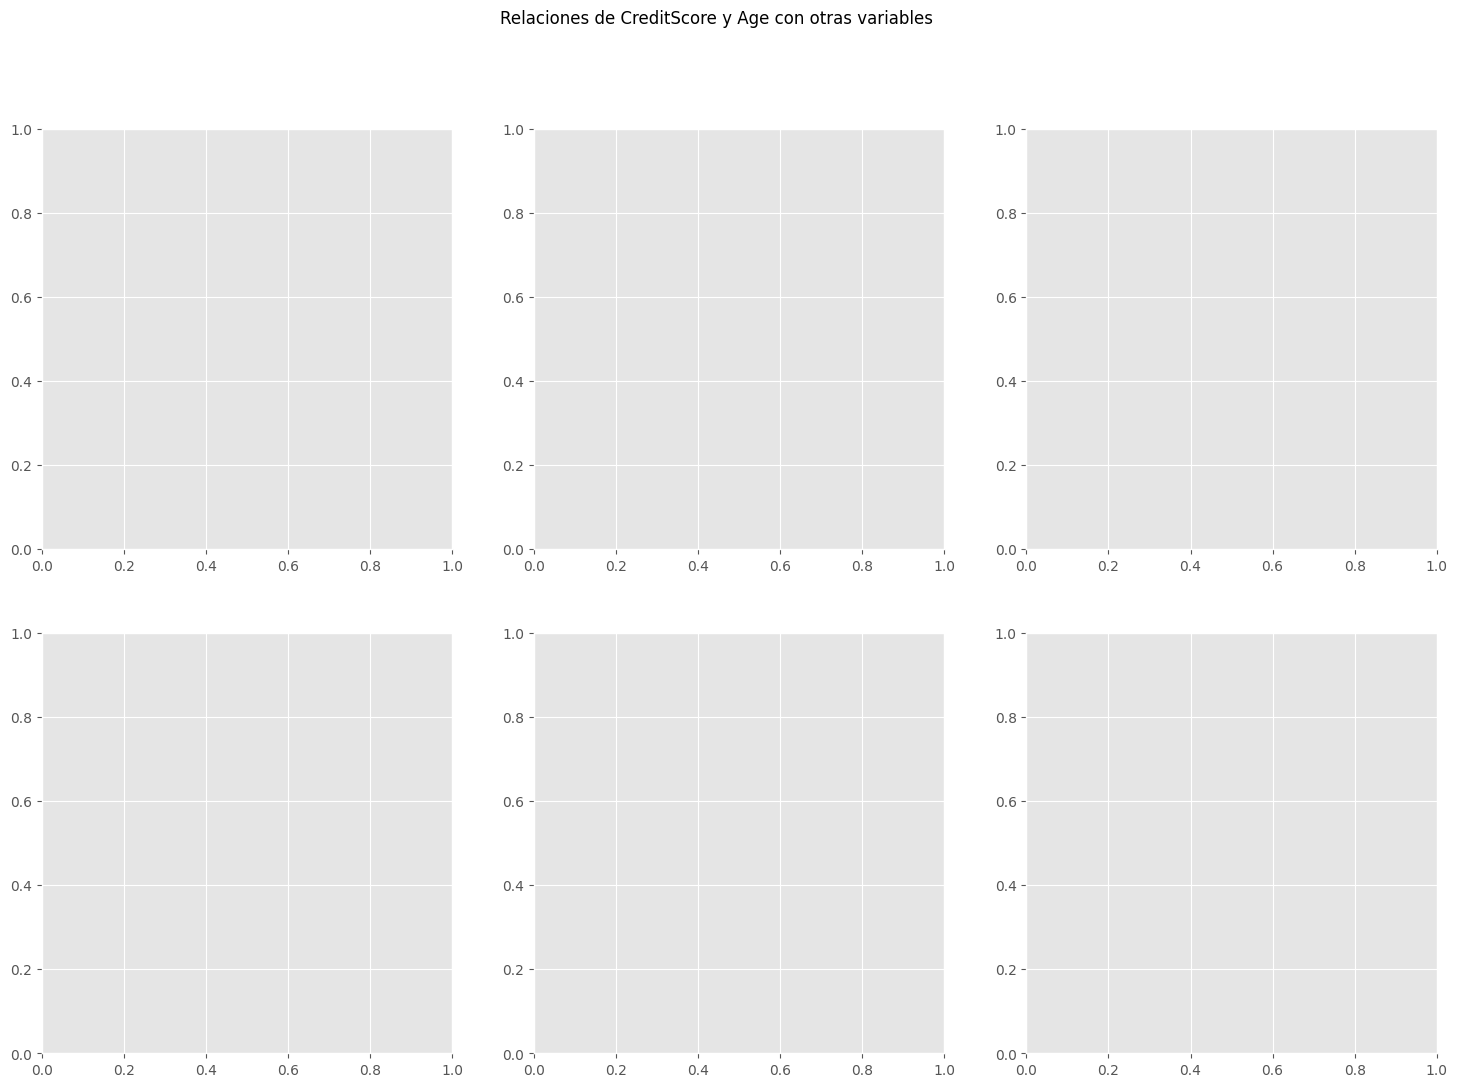

In [ ]:
# @title
# Scatter plots para CreditScore y Age con otras variables
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Relaciones de CreditScore y Age con otras variables')

for i, var in enumerate(['NumOfProducts', 'EstimatedSalary', 'Balance']):
    sns.scatterplot(data=X, x='CreditScore', y=var, ax=axes[0, i])
    sns.scatterplot(data=X, x='Age', y=var, ax=axes[1, i])

plt.tight_layout()
plt.show()

# Boxplot de NumOfProducts
plt.figure(figsize=(10, 6))
sns.boxplot(x='NumOfProducts', y='CreditScore', data=X)
plt.title('CreditScore por Número de Productos')
plt.show()

# Análisis de Outliers

In [ ]:
# @title
# Excluyendo las columnas especificadas
columns_to_exclude = ['RowNumber', 'CustomerId', 'HasCrCard', 'IsActiveMember', 'Exited']
df = churn_base.drop(columns=columns_to_exclude)

# Configuración de estilos para gráficos usando Seaborn directamente
sns.set(style="whitegrid")  # Cambia el estilo según tus preferencias

# Función para detectar outliers usando IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Función para detectar outliers usando Z-score
def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column]))
    return df[z_scores > threshold]

# Selección de columnas numéricas excluyendo las columnas especificadas
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns.tolist()]

# Visualización de outliers para variables numéricas
for col in numeric_cols:
    plt.figure(figsize=(12, 6))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(y=col, data=df)
    plt.title(f'Boxplot de {col}')

    # Diagrama de dispersión
    plt.subplot(1, 2, 2)
    sns.scatterplot(x=df.index, y=col, data=df)
    plt.title(f'Diagrama de dispersión de {col}')

    plt.tight_layout()
    plt.show()

    # Detección de outliers usando IQR
    outliers_iqr = detect_outliers_iqr(df, col)
    print(f"Outliers en {col} usando IQR: {len(outliers_iqr)}")

    # Detección de outliers usando Z-score
    outliers_zscore = detect_outliers_zscore(df, col)
    print(f"Outliers en {col} usando Z-score: {len(outliers_zscore)}")

* CreditScore: Presenta outliers significativos en la parte inferior de la distribución, con algunos valores extremadamente bajos (350-400).
* Age: Muestra una cantidad considerable de outliers en la parte superior de la distribución, con valores que se extienden hasta los 90 años aproximadamente.
* Tenure: No presenta outliers evidentes. La distribución es uniforme entre 0 y 10 años.
* Balance: Exhibe outliers notables en la parte superior de la distribución, con algunos saldos muy altos (por encima de 200,000).
* NumOfProducts: Tiene outliers claros en la parte superior, con valores de 3 y especialmente 4 productos siendo menos frecuentes.
* EstimatedSalary: No muestra outliers significativos, con una distribución relativamente uniforme entre 0 y 200,000.

# Análisis Comparativo Balance 0 vs Balance Positivo

Porcentaje de clientes con balance cero: 36.17%
Tasa de churn para clientes con balance: 0.24
Tasa de churn para clientes sin balance: 0.14
Media de CreditScore:
  - Con balance: 651.14
  - Sin balance: 649.45
Media de Age:
  - Con balance: 39.20
  - Sin balance: 38.43
Media de Tenure:
  - Con balance: 4.98
  - Sin balance: 5.07
Media de NumOfProducts:
  - Con balance: 1.39
  - Sin balance: 1.78
Media de IsActiveMember:
  - Con balance: 0.51
  - Sin balance: 0.52
Media de EstimatedSalary:
  - Con balance: 100717.35
  - Sin balance: 98983.56


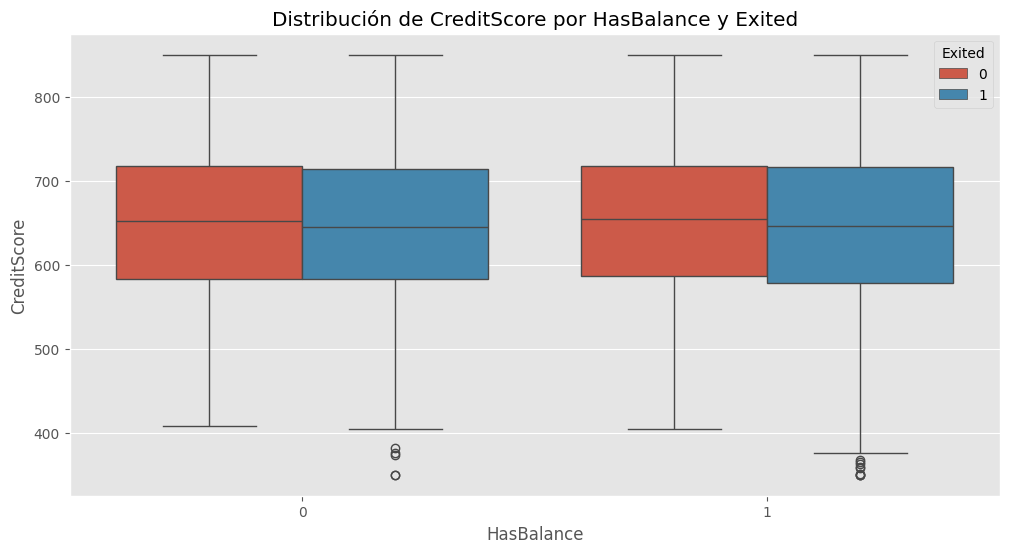

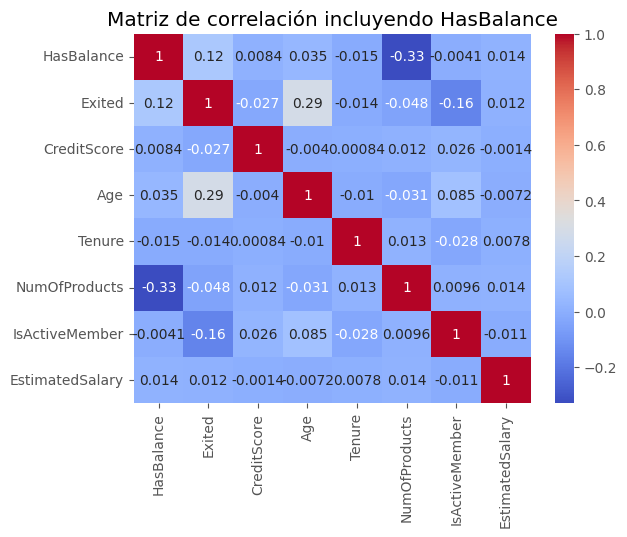

Proporción de clientes con balance por geografía:
Geography
France     0.517750
Germany    1.000000
Spain      0.515947
Name: HasBalance, dtype: float64


In [4]:
# @title
#Análisis comparativo Balance 0 vs Balance positivo

churn_base['HasBalance'] = (churn_base['Balance'] > 0).astype(int)

# Calcular el porcentaje de clientes con balance cero
zero_balance_percentage = (churn_base['HasBalance'] == 0).mean() * 100
print(f"Porcentaje de clientes con balance cero: {zero_balance_percentage:.2f}%")

# Calcular el tasa de churn para clientes con y sin balance
churn_rate_with_balance = churn_base[churn_base['HasBalance'] == 1]['Exited'].mean()
churn_rate_without_balance = churn_base[churn_base['HasBalance'] == 0]['Exited'].mean()
print(f"Tasa de churn para clientes con balance: {churn_rate_with_balance:.2f}")
print(f"Tasa de churn para clientes sin balance: {churn_rate_without_balance:.2f}")

features_to_compare = ['CreditScore', 'Age', 'Tenure', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary']
for feature in features_to_compare:
    mean_with_balance = churn_base[churn_base['HasBalance'] == 1][feature].mean()
    mean_without_balance = churn_base[churn_base['HasBalance'] == 0][feature].mean()
    print(f"Media de {feature}:")
    print(f"  - Con balance: {mean_with_balance:.2f}")
    print(f"  - Sin balance: {mean_without_balance:.2f}")
    import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='HasBalance', y='CreditScore', hue='Exited', data=churn_base)
plt.title('Distribución de CreditScore por HasBalance y Exited')
plt.show()

correlation_matrix = churn_base[['HasBalance', 'Exited', 'CreditScore', 'Age', 'Tenure', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación incluyendo HasBalance')
plt.show()

geo_balance = churn_base.groupby('Geography')['HasBalance'].mean()
print("Proporción de clientes con balance por geografía:")
print(geo_balance)

* Edad y Churn (0.29): A mayor edad, mayor probabilidad de churn.
* Número de Productos y Churn (-0.048): Más productos, menor probabilidad de churn.
* Miembros Activos y Churn (-0.16): Clientes activos tienen menos probabilidad de churn.
* Balance y Churn (0.12): Clientes con balance tienen mayor probabilidad de churn.
* Geografía y Balance: Alemania tiene 100% con Balance positivo, mientras que el resto es en torno al 50%.

# Análisis de Componentes Principales (PCA)

Se realizó para identificar patrones en los en los datos para descubrir relaciones entre las variables que no sean evidentes a simple vista y que podrían ser importantes para explicar el churn.

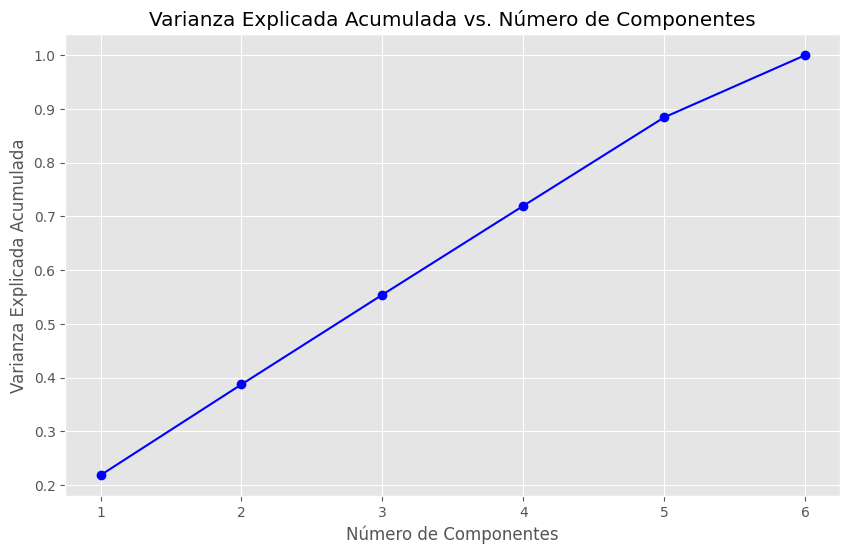

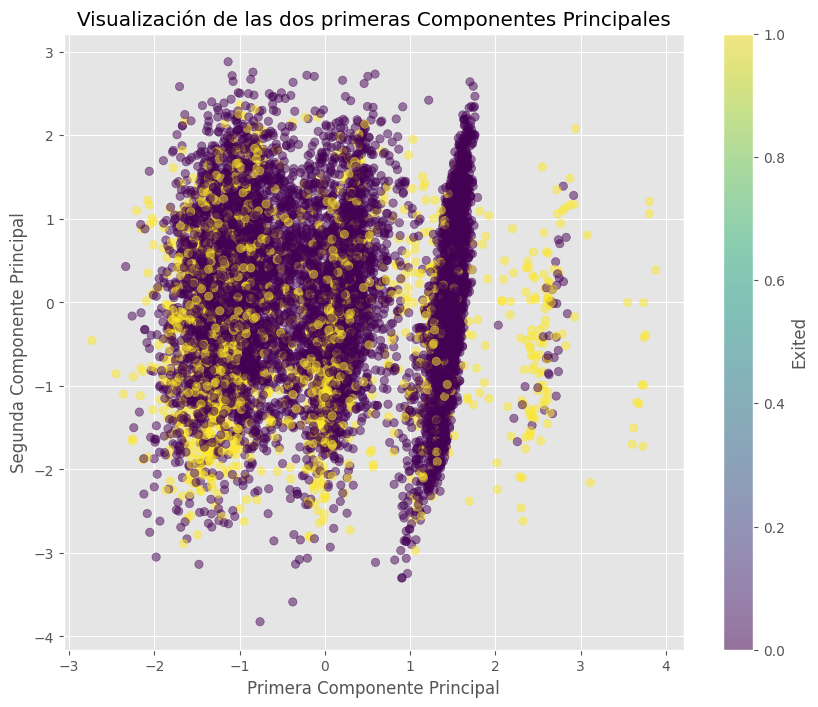

Matriz de cargas (loadings):
                      PC1       PC2       PC3       PC4       PC5       PC6
CreditScore      0.017534  0.123614  0.955392  0.144695  0.222540 -0.035736
Age             -0.154535 -0.479490 -0.152209  0.109749  0.843260  0.002918
Tenure           0.071373  0.586862 -0.067983 -0.689836  0.412435 -0.000803
Balance         -0.799753  0.111107  0.039438 -0.001640 -0.044511  0.587036
NumOfProducts    0.801408 -0.043723 -0.002119  0.070048  0.074084  0.587821
EstimatedSalary  0.008977  0.640126 -0.243171  0.691772  0.223343 -0.051919


In [3]:
# @title
numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X = churn_base[numeric_columns]

# 3. Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 5. Calcular la varianza explicada acumulada
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# 6. Visualizar la varianza explicada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 'bo-')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada vs. Número de Componentes')
plt.grid(True)
plt.show()

# 7. Visualizar los dos primeros componentes principales
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=churn_base['Exited'], cmap='viridis', alpha=0.5)
plt.xlabel('Primera Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.title('Visualización de las dos primeras Componentes Principales')
plt.colorbar(label='Exited')
plt.show()

# 8. Mostrar la contribución de cada variable a los componentes principales
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_matrix = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(len(numeric_columns))], index=numeric_columns)
print("Matriz de cargas (loadings):")
print(loading_matrix)

**Varianza explicada acumulada:**

Las 6 componentes principales explican casi el 100% de la varianza en los datos, 3 explican el 70% de la varianza.Esto sugiere que se podría reducir la dimensionalidad de los datos manteniendo la mayoría de la información.

**Visualización de las dos primeras componentes principales:**

 Se observa una separación en tres grupos distintos a lo largo del eje x,primera componente principal.

**La tabla de loadings:**
- PC1: Este está principalmente influenciado por el Balance y el NumOfProducts. Una alta variabilidad en el balance y el número de productos que posee un cliente explican gran parte de la varianza en los datos.
- PC2: Age, el EstimatedSalary y el Tenure son las variables que más contribuyen a este componente. Los clientes mayores, con menor salario estimado y menor tenencia tienden a agruparse aquí.
- PC3: CreditScore es la variable más influyente en este componente..
- PC4: EstimatedSalary y Tenure salario estimado y tiempo de tenencia influyen significativamente en la variabilidad en este componente.
- PC5: Age es la variable dominante en este componente, lo que sugiere que la variabilidad en la edad de los clientes se captura principalmente en este componente.
- PC6: Balance y NumOfProducts son las variables más influyentes.


# **Recomendaciones basadas en los hallazgos**

* 'CreditScore': Ofrecer productos financieros personalizados para clientes con
puntajes de crédito bajos para reducir el churn.
* 'Geography': Desarrollar estrategias de retención específicas para cada región, sobre todo en Alemania.
* 'Gender': Implementar campañas de marketing dirigidas a grupos de género específicos para aumentar la lealtad.
* 'Age': Crear programas de fidelización dirigidos a grupos de edad específicos.
* 'Tenure': Reconocer y recompensar a los clientes leales de largo plazo.
* 'Balance': Ofrecer incentivos para clientes con altos saldos para mantener su compromiso con el banco.
* 'NumOfProducts': Incentivar la contratación de múltiples productos para aumentar la satisfacción y reducir el churn.
* 'HasCrCard': Fomentar el uso de tarjetas de crédito a través de recompensas y beneficios adicionales, como puede ser puntos de acuerdo al gasto mensual.
* 'IsActiveMember': Promover la participación activa de los clientes a través de eventos y ofertas exclusivas.
* 'EstimatedSalary': Dar asesoramiento financiero personalizado para clientes según su nivel de ingresos.



# Preparación modelado de datos

Detallamos a continuación algunas de las técnicas que utilizamos y su justificación:

**estandarización de variables** para asegurar que todas las variables influyan de manera equitativa en los modelos, evitando que las variables con mayores magnitudes dominen sobre otras más pequeñas, mejorando así el rendimiento del modelo.

**Uso de One-Hot Encoding**
Para convertir las variables categóricas en representaciones numéricas sin asignar un orden implícito.Esto para que los modelos de machine learning procesen adecuadamente las variables categóricas y no ordinales.

**SMOTE (Synthetic Minority Over-sampling Technique)**
Se usó debido al desbalance del dataset, en particular se utilizó SMOTE, que genera nuevas instancias sintéticas de la clase minoritaria y evita que el modelo se sesgue hacia la clase mayoritaria. También se realizó pruebas con las mismas técnicas y con las clases desbalanceadas para comparar el impacto en las métricas.

**GridSearchCV**
Se utilizó para realizar una búsqueda exhaustiva de los mejores hiperparámetros para cada modelo, optimizando el rendimiento a través de cross-validation de 5 folds (cv=5), lo que asegura una evaluación robusta sin sobreajuste.

In [ ]:
# Crear un dataframe vacío para almacenar las métricas
metrics_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

# Función para agregar métricas al dataframe
def add_metrics_to_df(model_name, y_test, predictions):
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    metrics_df.loc[len(metrics_df)] = [model_name, accuracy, precision, recall, f1]

In [ ]:
# Preprocesamiento de datos
churn_base = churn_base.drop(columns=["RowNumber", "CustomerId", "Surname"])
churn_base = pd.get_dummies(churn_base, columns=['Geography', 'Gender'], drop_first=True)

# Separar características (X) y objetivo (y)
X = churn_base.drop(columns=['Exited'])
y = churn_base['Exited']

# División de datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalado de características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



**Modelo de Random Forest**

Utilizamos este modelo por habilidad para capturar relaciones no lineales y complejas entre las variables sin tener que hacer muchos ajustes de hiperparámetros, además de ser un modelo interpretable en términos de la importancia de las variables.

In [ ]:
# Entrenamiento de un modelo de bosque aleatorio
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluación del modelo
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8673333333333333
Confusion Matrix:
 [[2328   88]
 [ 310  274]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      2416
           1       0.76      0.47      0.58       584

    accuracy                           0.87      3000
   macro avg       0.82      0.72      0.75      3000
weighted avg       0.86      0.87      0.85      3000



In [ ]:
# Definir el modelo
model = RandomForestClassifier(random_state=42)

# Definir los hiperparámetros a ajustar
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árboles en el bosque
    'max_depth': [None, 10, 20, 30],  # Profundidad máxima de cada árbol
    'min_samples_split': [2, 5, 10],  # Número mínimo de muestras requeridas para dividir un nodo
    'min_samples_leaf': [1, 2, 4]     # Número mínimo de muestras requeridas en cada hoja del árbol
}

# Configurar la búsqueda en cuadrícula con validación cruzada
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

# Ejecutar la búsqueda en cuadrícula en los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Obtener los mejores hiperparámetros encontrados
best_params = grid_search.best_params_
print("Mejores hiperparámetros encontrados:", best_params)

# Obtener la precisión del mejor modelo
best_model = grid_search.best_estimator_
accuracy = grid_search.best_score_
print(f"Precisión del mejor modelo: {accuracy:.2f}")

Mejores hiperparámetros encontrados: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Precisión del mejor modelo: 0.86


In [ ]:
# Modelo con parámetros óptimos:
X = churn_base.drop(columns=['Exited'])  # Todas las columnas excepto 'Exited'
y = churn_base['Exited']                # La columna 'Exited' como variable objetivo

# División de datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Definir el modelo con los hiperparámetros óptimos encontrados
best_model_rf = RandomForestClassifier(max_depth=20, min_samples_leaf=4, min_samples_split=10, n_estimators=100, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
best_model_rf.fit(X_train, y_train)

# Hacer predicciones sobre los datos de prueba
y_pred_rfd = best_model_rf.predict(X_test)

# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred_rfd)
print("Precisión del modelo con hiperparámetros óptimos:", accuracy)

# Imprimir la matriz de confusión
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rfd))

# Imprimir el reporte de clasificación
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rfd))
add_metrics_to_df('RandomForest', y_test, y_pred_rfd)

Precisión del modelo con hiperparámetros óptimos: 0.868

Confusion Matrix:
[[2339   77]
 [ 319  265]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2416
           1       0.77      0.45      0.57       584

    accuracy                           0.87      3000
   macro avg       0.83      0.71      0.75      3000
weighted avg       0.86      0.87      0.85      3000



**Random Forest con SMOTE**

In [ ]:
# Separar características y variable objetivo
X = churn_base.drop(columns=['Exited'])  # Todas las columnas excepto 'Exited'
y = churn_base['Exited']                # La columna 'Exited' como variable objetivo

# División de datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Aplicar SMOTE para balancear las clases en el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Definir el modelo con los hiperparámetros óptimos encontrados
best_model_rf_smote = RandomForestClassifier(max_depth=20, min_samples_leaf=4, min_samples_split=10, n_estimators=100, random_state=42)

# Entrenar el modelo con los datos balanceados
best_model_rf_smote.fit(X_train_balanced, y_train_balanced)

# Hacer predicciones sobre los datos de prueba
y_pred_rf = best_model_rf_smote.predict(X_test)

# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred_rf)
print("Precisión del modelo con hiperparámetros óptimos:", accuracy)

# Imprimir la matriz de confusión
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Imprimir el reporte de clasificación
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
add_metrics_to_df('RandomForest-SMOTE', y_test, y_pred_rf)

Precisión del modelo con hiperparámetros óptimos: 0.829

Confusion Matrix:
[[2116  300]
 [ 213  371]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      2416
           1       0.55      0.64      0.59       584

    accuracy                           0.83      3000
   macro avg       0.73      0.76      0.74      3000
weighted avg       0.84      0.83      0.83      3000



**Modelo XGBoost**

Aquí se usó XGBoost que es un algoritmo de boosting altamente eficiente que ofrece excelentes resultados en problemas de clasificación y además optimiza iterativamente los errores del modelo, lo que le permite lograr un buen rendimiento en términos de precisión y capacidad de generalización.

In [ ]:
# 6. Definir el modelo de XGBoost
xgb_model = XGBClassifier(random_state=42)

# 7. Definir los hiperparámetros para optimización
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# 8. Aplicar búsqueda de hiperparámetros con GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train, y_train)

# 9. Imprimir los mejores parámetros
print(f"Mejores hiperparámetros: {grid_search_xgb.best_params_}")

# 10. Hacer predicciones en el conjunto de prueba
y_pred_xgb = grid_search_xgb.predict(X_test)

# 11. Evaluar el modelo XGBoost
print("Accuracy (XGBoost):", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix (XGBoost):\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report (XGBoost):\n", classification_report(y_test, y_pred_xgb))
add_metrics_to_df('XGBoost', y_test, y_pred_xgb)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Mejores hiperparámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Accuracy (XGBoost): 0.871
Confusion Matrix (XGBoost):
 [[2336   80]
 [ 307  277]]
Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      2416
           1       0.78      0.47      0.59       584

    accuracy                           0.87      3000
   macro avg       0.83      0.72      0.76      3000
weighted avg       0.86      0.87      0.86      3000



XGBoost con SMOTE

In [ ]:
# 5. Aplicación de SMOTE para balanceo de clases
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 6. Definir el modelo de XGBoost
xgb_model = XGBClassifier(random_state=42)

# 7. Definir los hiperparámetros para optimización
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# 8. Aplicar búsqueda de hiperparámetros con GridSearchCV
grid_search_xgb_smote = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_xgb_smote.fit(X_train_balanced, y_train_balanced)

# 9. Imprimir los mejores parámetros
print(f"Mejores hiperparámetros: {grid_search_xgb_smote.best_params_}")

# 10. Hacer predicciones en el conjunto de prueba
y_pred_xgb = grid_search_xgb_smote.predict(X_test)

# 11. Evaluar el modelo XGBoost
print("Accuracy (XGBoost):", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix (XGBoost):\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report (XGBoost):\n", classification_report(y_test, y_pred_xgb))
add_metrics_to_df('XGBoost_SMOTE', y_test, y_pred_xgb)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Mejores hiperparámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.9}
Accuracy (XGBoost): 0.8233333333333334
Confusion Matrix (XGBoost):
 [[2106  310]
 [ 220  364]]
Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       0.91      0.87      0.89      2416
           1       0.54      0.62      0.58       584

    accuracy                           0.82      3000
   macro avg       0.72      0.75      0.73      3000
weighted avg       0.83      0.82      0.83      3000



**Modelo Regresión Logística**

La regresión logística es un modelo base simple e interpretable que permite obtener probabilidades de churn. Tiene la virtud de ser facil para interpretar los coeficientes de las variables, proporcionando información clara sobre el impacto de cada característica en la probabilidad de churn.

In [ ]:
# 6. Definir el modelo de Regresión Logística
logreg_model = LogisticRegression(random_state=42, max_iter=1000)

# 7. Definir los hiperparámetros para optimización
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
}

# 8. Aplicar búsqueda de hiperparámetros con GridSearchCV
grid_search_logreg = GridSearchCV(estimator=logreg_model, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=1)
grid_search_logreg.fit(X_train, y_train)

# 9. Imprimir los mejores parámetros
print(f"Mejores hiperparámetros (Regresión Logística): {grid_search_logreg.best_params_}")

# 10. Hacer predicciones en el conjunto de prueba
y_pred_logreg = grid_search_logreg.predict(X_test)

# 11. Evaluar el modelo de Regresión Logística
print("Accuracy (Regresión Logística):", accuracy_score(y_test, y_pred_logreg))
print("Confusion Matrix (Regresión Logística):\n", confusion_matrix(y_test, y_pred_logreg))
print("Classification Report (Regresión Logística):\n", classification_report(y_test, y_pred_logreg))
add_metrics_to_df('LogReg', y_test, y_pred_logreg)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores hiperparámetros (Regresión Logística): {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy (Regresión Logística): 0.8123333333333334
Confusion Matrix (Regresión Logística):
 [[2322   94]
 [ 469  115]]
Classification Report (Regresión Logística):
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      2416
           1       0.55      0.20      0.29       584

    accuracy                           0.81      3000
   macro avg       0.69      0.58      0.59      3000
weighted avg       0.78      0.81      0.77      3000



Modelo Regresión Logística con SMOTE

In [ ]:
# 5. Aplicación de SMOTE para balanceo de clases
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 6. Definir el modelo de Regresión Logística
logreg_model = LogisticRegression(random_state=42, max_iter=1000)

# 7. Definir los hiperparámetros para optimización
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
}

# 8. Aplicar búsqueda de hiperparámetros con GridSearchCV
grid_search_logreg_smote= GridSearchCV(estimator=logreg_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_logreg_smote.fit(X_train_balanced, y_train_balanced)

# 9. Imprimir los mejores parámetros
print(f"Mejores hiperparámetros (Regresión Logística): {grid_search_logreg_smote.best_params_}")

# 10. Hacer predicciones en el conjunto de prueba
y_pred_logreg = grid_search_logreg_smote.predict(X_test)

# 11. Evaluar el modelo de Regresión Logística
print("Accuracy (Regresión Logística):", accuracy_score(y_test, y_pred_logreg))
print("Confusion Matrix (Regresión Logística):\n", confusion_matrix(y_test, y_pred_logreg))
print("Classification Report (Regresión Logística):\n", classification_report(y_test, y_pred_logreg))
add_metrics_to_df('LogReg_SMOTE', y_test, y_pred_logreg)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores hiperparámetros (Regresión Logística): {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy (Regresión Logística): 0.7386666666666667
Confusion Matrix (Regresión Logística):
 [[1876  540]
 [ 244  340]]
Classification Report (Regresión Logística):
               precision    recall  f1-score   support

           0       0.88      0.78      0.83      2416
           1       0.39      0.58      0.46       584

    accuracy                           0.74      3000
   macro avg       0.64      0.68      0.65      3000
weighted avg       0.79      0.74      0.76      3000



In [ ]:
print(metrics_df.to_string(index=False))


             Model  Accuracy  Precision   Recall  F1-Score
      RandomForest  0.868000   0.774854 0.453767  0.572354
RandomForest-SMOTE  0.829000   0.552906 0.635274  0.591235
           XGBoost  0.871000   0.775910 0.474315  0.588735
     XGBoost_SMOTE  0.823333   0.540059 0.623288  0.578696
            LogReg  0.812333   0.550239 0.196918  0.290038
      LogReg_SMOTE  0.738667   0.386364 0.582192  0.464481


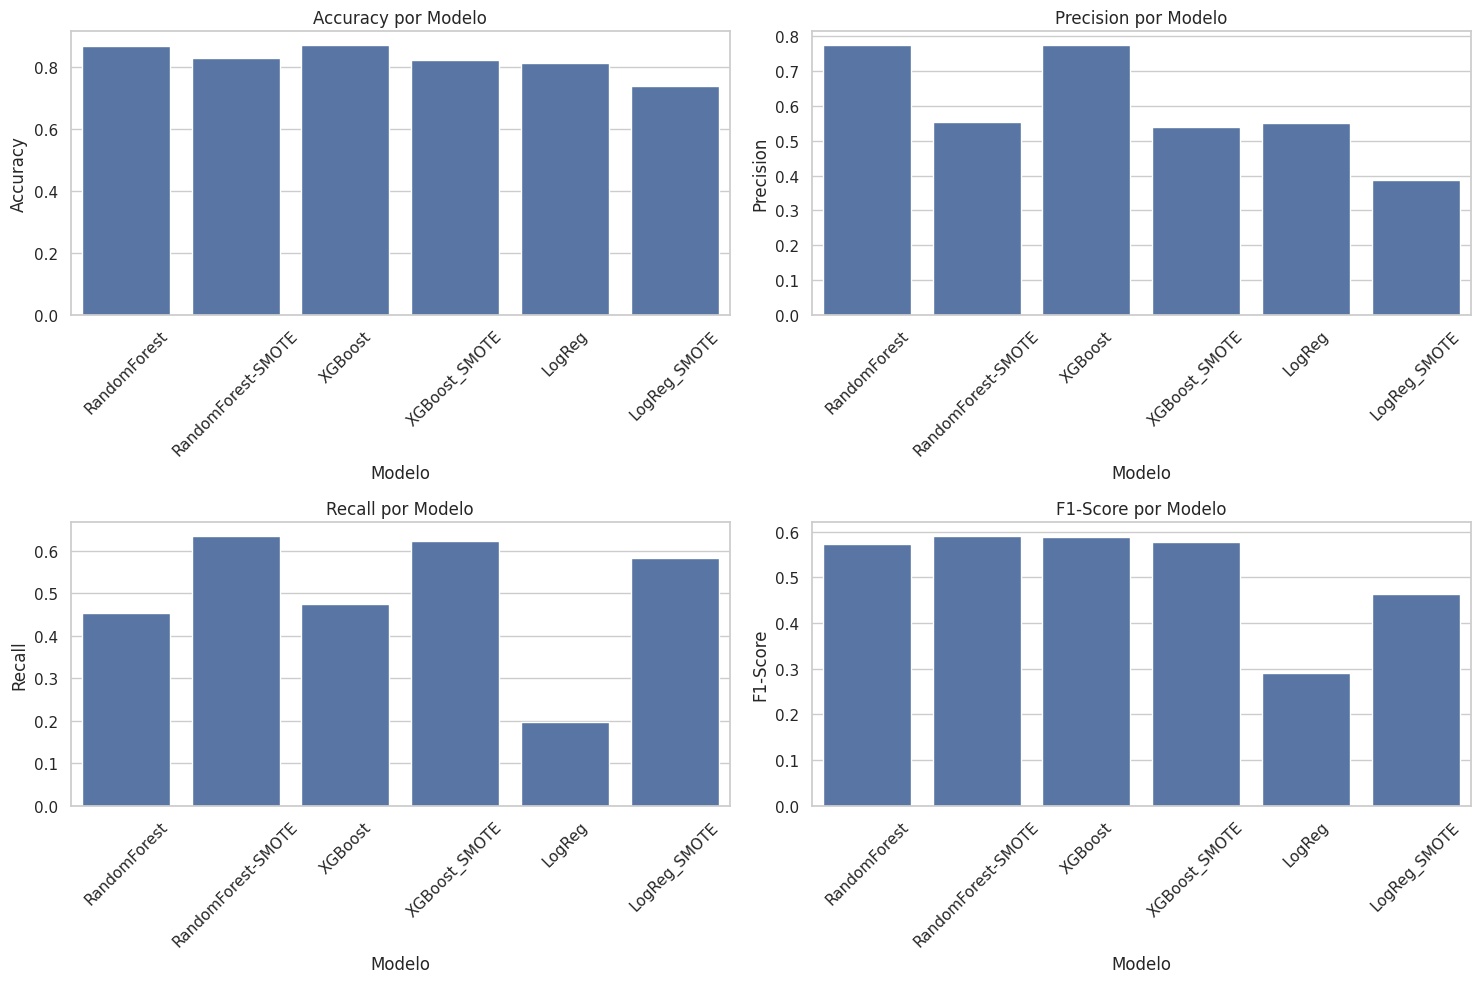

In [ ]:
# Establecer el estilo para las gráficas
sns.set(style="whitegrid")

# Crear subplots para cada métrica
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfica para Accuracy
sns.barplot(x="Model", y="Accuracy", data=metrics_df, ax=axes[0, 0])
axes[0, 0].set_title('Accuracy por Modelo')
axes[0, 0].set_xlabel('Modelo')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# Gráfica para Precision
sns.barplot(x="Model", y="Precision", data=metrics_df, ax=axes[0, 1])
axes[0, 1].set_title('Precision por Modelo')
axes[0, 1].set_xlabel('Modelo')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].tick_params(axis='x', rotation=45)

# Gráfica para Recall
sns.barplot(x="Model", y="Recall", data=metrics_df, ax=axes[1, 0])
axes[1, 0].set_title('Recall por Modelo')
axes[1, 0].set_xlabel('Modelo')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].tick_params(axis='x', rotation=45)

# Gráfica para F1-Score
sns.barplot(x="Model", y="F1-Score", data=metrics_df, ax=axes[1, 1])
axes[1, 1].set_title('F1-Score por Modelo')
axes[1, 1].set_xlabel('Modelo')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].tick_params(axis='x', rotation=45)

# Ajustar los espacios entre los subplots
plt.tight_layout()

# Mostrar la gráfica
plt.show()


**Curva Precisión-recall**



Se eligió ya que en problemas de clasificación desbalanceada como el churn, la curva de precisión-recall es más informativa que la curva ROC. Muestra el trade-off entre precisión y recall (qué tan bien se identifican los positivos reales) a medida que varía el umbral de clasificación.
Esto permite evaluar el rendimiento del modelo en datasets desbalanceados, donde el recall (capturar la mayoría de los clientes que abandonan) es crítico, y así facilitar elegir un umbral adecuado para la clasificación que maximice ambas métricas.


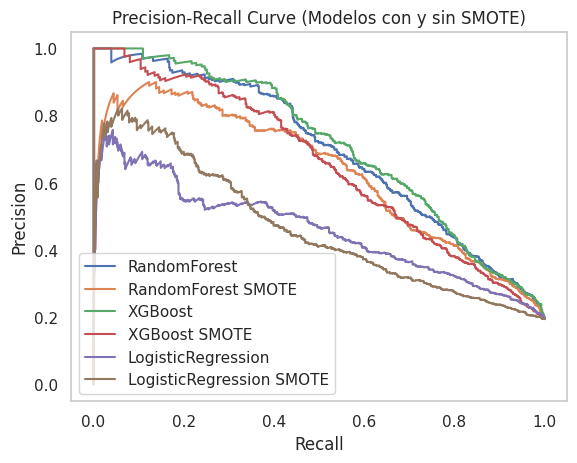

In [ ]:
# Función para graficar la curva Precision-Recall
def plot_precision_recall(model_name, y_test, y_probs, smote=False):
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    label = f"{model_name}{' SMOTE' if smote else ''}"
    plt.plot(recall, precision, label=label)

# Generar probabilidades para cada modelo y graficar la curva para modelos con y sin SMOTE

# RandomForest
y_probs_rf = best_model_rf.predict_proba(X_test)[:, 1]  # Modelo sin SMOTE
plot_precision_recall('RandomForest', y_test, y_probs_rf)

y_probs_rf_smote = best_model_rf_smote.predict_proba(X_test)[:, 1]  # Modelo con SMOTE
plot_precision_recall('RandomForest', y_test, y_probs_rf_smote, smote=True)

# XGBoost
y_probs_xgb = grid_search_xgb.predict_proba(X_test)[:, 1]  # Modelo sin SMOTE
plot_precision_recall('XGBoost', y_test, y_probs_xgb)

y_probs_xgb_smote = grid_search_xgb_smote.predict_proba(X_test)[:, 1]  # Modelo con SMOTE
plot_precision_recall('XGBoost', y_test, y_probs_xgb_smote, smote=True)


# Regresión Logística
y_probs_logreg = grid_search_logreg.predict_proba(X_test)[:, 1]  # Modelo sin SMOTE
plot_precision_recall('LogisticRegression', y_test, y_probs_logreg)

y_probs_logreg_smote = grid_search_logreg_smote.predict_proba(X_test)[:, 1]  # Modelo con SMOTE
plot_precision_recall('LogisticRegression', y_test, y_probs_logreg_smote, smote=True)

# Configurar la gráfica
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Modelos con y sin SMOTE)')
plt.legend(loc='best')
plt.grid()
plt.show()